#Neural Networks backpropagation for MLPs

- Implement a Multi-Layer Perceptron (MLP) with one hidden layer.
- Use Backpropagation to train it.
- Train on MNIST (usually first few classes or all 10).
- Report accuracy and confusion matrix.

In [63]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
print("Loading MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data.astype(float) / 255.0
y = mnist.target.astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train samples: {len(X_train)} | Test samples: {len(X_test)}")

Loading MNIST...
Train samples: 56000 | Test samples: 14000


In [65]:
# ====================== Training ======================
input_size = 784
hidden_size = 70
output_size = 10
lr = 2             # at 0.9 achieving 90% accuracy
epochs = 120

In [66]:
# Initialize weights
W1 = np.random.randn(input_size, hidden_size) * 0.01
W2 = np.random.randn(hidden_size, output_size) * 0.01

In [67]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

In [68]:
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [69]:
print("Training started...")

for epoch in range(epochs):
    # Forward pass
    Z1 = X_train @ W1
    A1 = sigmoid(Z1)
    Z2 = A1 @ W2
    A2 = softmax(Z2)

    # Backward pass
    y_onehot = np.eye(10)[y_train]
    dZ2 = A2 - y_onehot
    dW2 = A1.T @ dZ2 / len(X_train)
    dZ1 = (dZ2 @ W2.T) * (A1 * (1 - A1))
    dW1 = X_train.T @ dZ1 / len(X_train)

    # Update
    W1 -= lr * dW1
    W2 -= lr * dW2

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs} completed")

Training started...
Epoch 20/120 completed
Epoch 40/120 completed
Epoch 60/120 completed
Epoch 80/120 completed
Epoch 100/120 completed
Epoch 120/120 completed


In [70]:
# ====================== Test ======================
Z1_test = X_test @ W1
A1_test = sigmoid(Z1_test)
Z2_test = A1_test @ W2
y_pred = np.argmax(Z2_test, axis=1)

acc = accuracy_score(y_test, y_pred) * 100
print(f"\nFinal Test Accuracy: {acc:.2f}%")


Final Test Accuracy: 90.70%


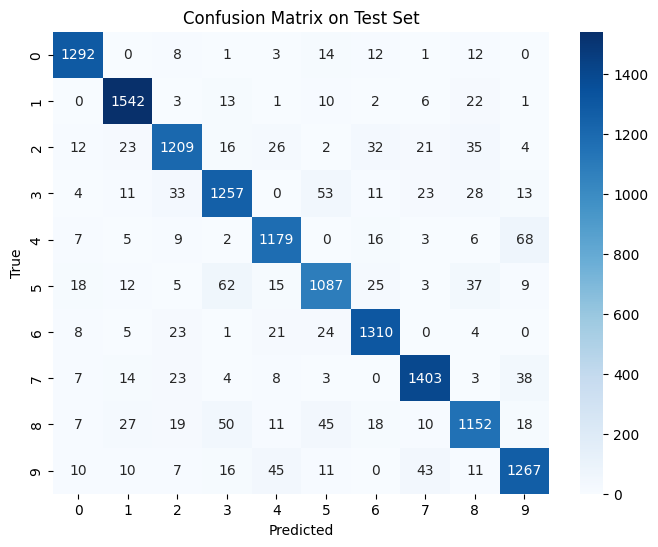

In [71]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix on Test Set')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

## Key insight
- You need softmax.m (same as previous assignments).
- This is a basic 1-hidden-layer MLP with backprop.
- Tune hidden_size, epochs, and lr (learning rate) for better accuracy.
- hidden_size and lr are the most imacting factors of NN